<a href="https://colab.research.google.com/github/azzindani/Kestrel/blob/main/Kestrel_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
# QT-1 — Clone / update repo + install deps (--deps-only skips .env/DB/exchange checks)
!git clone https://github.com/azzindani/kestrel.git /content/kestrel 2>/dev/null || git -C /content/kestrel pull --ff-only
%cd /content/kestrel
!bash scripts/install.sh --deps-only

Already up to date.
/content/kestrel
Checking Python version...
[GO] Python 3.12
Installing system packages...
Reading package lists...
Building dependency tree...
Reading state information...
postgresql-client is already the newest version (14+238).
python3.12-venv is already the newest version (3.12.13-1+jammy1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
[GO] System packages (python3.12-venv, postgresql-client)
Setting up venv...
Installing dependencies (venv)...
[GO] Dependencies installed (venv)
Installing dependencies (system Python)...
[GO] Dependencies installed (system Python)

[GO] — dependencies ready (--deps-only mode).


In [35]:
# QT-2 — Fetch 90 days BTC/USDT 5m candles + build indicators + regime
# Fetch via script (tries bybit → okx → kucoin; no API key required).
import sys, os, json as _json
from collections import deque

sys.path.insert(0, '/content/kestrel')
os.chdir('/content/kestrel')

from src.config import Candle, Rejection, compute_candle_geometry, load_params
from src.signal.indicators import compute_all_indicators
from src.signal.regime import classify_regime

!python scripts/fetch_ohlcv.py --pair BTC/USDT --tf 5m --days 90 --out /tmp/ohlcv.json

ohlcvs = _json.loads(open('/tmp/ohlcv.json').read())
print(f'Loaded {len(ohlcvs):,} raw candles')

params = load_params('params.json')
buf    = deque(maxlen=200)
candles: list = []

for i, row in enumerate(ohlcvs):
    ts, o, h, l, c, v = row
    geom = compute_candle_geometry(o, h, l, c)

    raw = Candle(bot_id='qt', ts=ts, pair='BTCUSDT', timeframe='5m',
                 open=o, high=h, low=l, close=c, volume=v, **geom)
    buf.append(raw)

    inds = compute_all_indicators(list(buf), ema_fast=params.ema_fast,
                                  ema_slow=params.ema_slow)

    # Write indicators to buf[-1] BEFORE calling classify_regime so it
    # sees the real volume_ratio (not None → fallback 1.0 → always TRENDING).
    buf[-1] = Candle(bot_id='qt', ts=ts, pair='BTCUSDT', timeframe='5m',
                     open=o, high=h, low=l, close=c, volume=v,
                     regime=None, **geom, **inds)

    reg = classify_regime(list(buf), params)
    rs  = reg.regime.value if not isinstance(reg, Rejection) else None

    full = Candle(bot_id='qt', ts=ts, pair='BTCUSDT', timeframe='5m',
                  open=o, high=h, low=l, close=c, volume=v,
                  regime=rs, **geom, **inds)
    buf[-1] = full
    candles.append(full)

    if (i + 1) % 5000 == 0:
        print(f'  {i+1:,}/{len(ohlcvs):,}...', end='\r')

regime_counts = {}
for c in candles:
    k = c.regime or 'None'
    regime_counts[k] = regime_counts.get(k, 0) + 1
total = len(candles)
print(f'OK  {total:,} candles with indicators + regime')
for reg, n in sorted(regime_counts.items()):
    print(f'  {reg:10}  {n:5d}  ({n/total*100:.0f}%)')


Fetching 90d BTC/USDT 5m via kucoin...
OK  25,920 candles
Written to /tmp/ohlcv.json
Loaded 25,920 raw candles
OK  25,920 candles with indicators + regime
  None         9094  (35%)
  RANGING     10425  (40%)
  TRENDING     5999  (23%)
  VOLATILE      402  (2%)


Debug window: 560 candles · 498 evaluations · 1 fired · 1 closed
Top rejection reasons:
  pattern     no_pattern_fired                                           289  (58%)
  regime      quiet_regime                                               193  (39%)
  trend       no_trend_alignment                                          12  (2%)
  volume      volume_ratio_below_threshold:0.991<1.560                     1  (0%)
  volume      volume_ratio_below_threshold:0.736<1.300                     1  (0%)
  volume      volume_ratio_below_threshold:1.064<1.170                     1  (0%)

── Out-of-Sample Verdict ─────────────────────────────
  [FAIL]  Win rate > 55%                  44.4%
  [FAIL]  Avg PnL/trade > $0.018          $-0.2718
  [FAIL]  Max drawdown < 30%              522.4%
  [FAIL]  Sharpe > 0                      -141.36
  [FAIL]  Trades >= 20                    9
  Close reasons: {'timeout': 2, 'take_profit': 3, 'stop_loss': 4}

  [NO-GO]


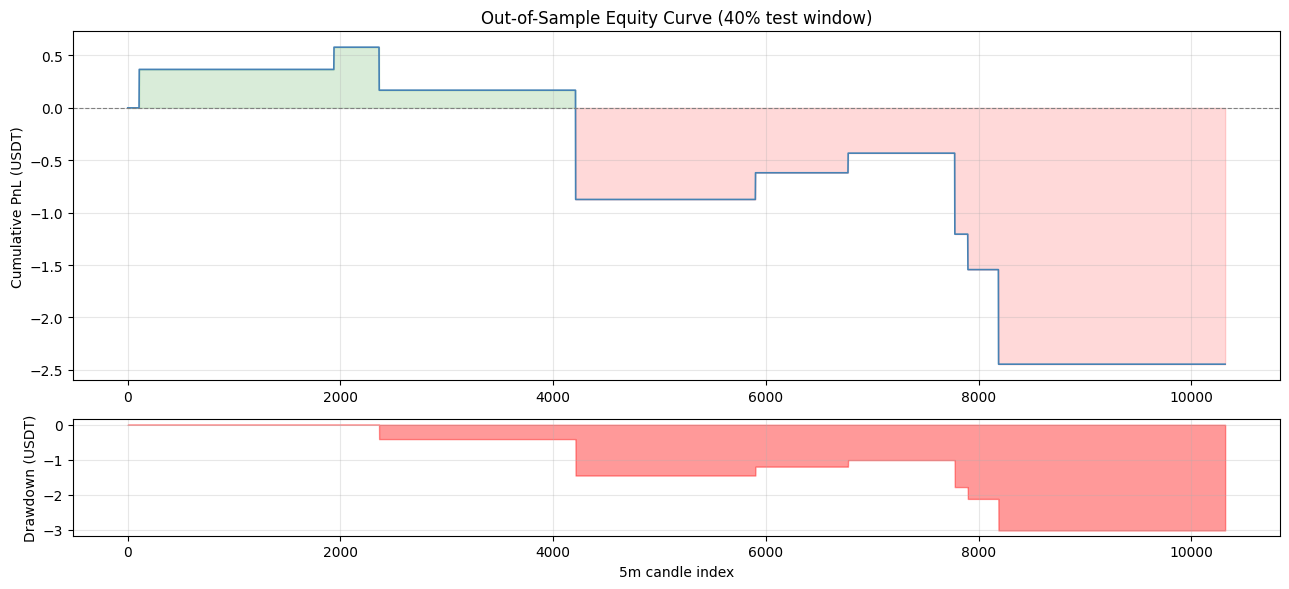

In [36]:
# QT-3 — Walk-forward backtest + verdict + equity curve
import os, matplotlib.pyplot as plt
from collections import Counter
from src.config import AppConfig
from src.backtest.runner import walk_forward, run_backtest

# Build config dict without touching os.environ.
# Linux sets ENV=/root/.bashrc (shell startup file), which would break
# AppConfig.from_mapping(os.environ) — so we use a standalone dict.
_cfg = {
    'ENV':'dev','BOT_ID':'qt','EXCHANGE':'bybit',
    'API_KEY':'x','API_SECRET':'x','TESTNET':'true',
    'DB_HOST':'localhost','DB_PORT':'5432','DB_NAME':'kestrel',
    'DB_USER':'kestrel','DB_PASSWORD':'x',
    'PAIR':'BTCUSDT','TIMEFRAME_ENTRY':'5m','TIMEFRAME_REGIME':'15m',
    'LEVERAGE':'20','BUCKET_SIZE_USDT':'10.0','MAX_ACTIVE_BUCKETS':'1',
    'TELEGRAM_TOKEN':'x','TELEGRAM_CHAT_ID':'0','LOG_LEVEL':'DEBUG',
}
cfg = AppConfig.from_mapping(_cfg)

# ── Rejection breakdown (first 560 candles) ──────────────────────────────
debug    = run_backtest(candles[:560], params, cfg)
n_evals  = len(debug['signals'])
n_fired  = sum(1 for s in debug['signals'] if s.get('outcome') == 'fired')
print(f'Debug window: 560 candles · {n_evals} evaluations · {n_fired} fired · {len(debug["trades"])} closed')
if n_evals:
    reasons = Counter(
        (s.get('stage','?'), s.get('reason','?')[:55])
        for s in debug['signals'] if s.get('outcome') == 'rejected'
    )
    print('Top rejection reasons:')
    for (stage, reason), count in reasons.most_common(8):
        print(f'  {stage:10}  {reason:<55}  {count:5}  ({count/n_evals*100:.0f}%)')
print()

# ── Walk-forward ─────────────────────────────────────────────────────────
results = walk_forward(candles, params, cfg)
oos     = results['out_sample']

checks = [
    ('Win rate > 55%',         oos.get('win_rate',0) >= 0.55,  f'{oos.get("win_rate",0)*100:.1f}%'),
    ('Avg PnL/trade > $0.018', oos.get('avg_pnl_usdt',0) >= 0.018, f'${oos.get("avg_pnl_usdt",0):.4f}'),
    ('Max drawdown < 30%',     oos.get('max_drawdown_pct',100) <= 30, f'{oos.get("max_drawdown_pct",100):.1f}%'),
    ('Sharpe > 0',             oos.get('sharpe_ratio',0) > 0,   f'{oos.get("sharpe_ratio",0):.2f}'),
    ('Trades >= 20',           oos.get('total_trades',0) >= 20, f'{oos.get("total_trades",0)}'),
]
all_pass = True
print('── Out-of-Sample Verdict ─────────────────────────────')
for label, passed, val in checks:
    all_pass = all_pass and passed
    print(f'  [{"PASS" if passed else "FAIL"}]  {label:<30}  {val}')
print(f'  Close reasons: {oos.get("close_reasons",{})}')
print(f'\n  {"[GO]" if all_pass else "[NO-GO]"}')

# ── Equity curve ─────────────────────────────────────────────────────────
split  = int(len(candles) * 0.6)
equity = run_backtest(candles[split:], params, cfg)['equity_curve']
peak   = 0.0
dds    = []
for e in equity:
    peak = max(peak, e)
    dds.append(e - peak)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [3,1]})
ax1.plot(equity, lw=1.2, color='steelblue')
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.fill_between(range(len(equity)), equity, 0, where=[e>=0 for e in equity], alpha=0.15, color='green')
ax1.fill_between(range(len(equity)), equity, 0, where=[e<0  for e in equity], alpha=0.15, color='red')
ax1.set_title('Out-of-Sample Equity Curve (40% test window)', fontsize=12)
ax1.set_ylabel('Cumulative PnL (USDT)'); ax1.grid(True, alpha=0.3)
ax2.fill_between(range(len(dds)), dds, 0, color='red', alpha=0.4)
ax2.set_ylabel('Drawdown (USDT)'); ax2.set_xlabel('5m candle index'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


In [37]:
%%bash
# Cell 0 — Kill existing Kestrel processes + clean state
pkill -f "src.engine.daemon"   2>/dev/null || true
pkill -f "src.engine.watchdog" 2>/dev/null || true
sleep 2
rm -f /content/kestrel/kestrel.pid
echo "OK  Environment clean"

OK  Environment clean


In [38]:
# Cell 1 — Clone / update repo
!git clone https://github.com/azzindani/kestrel.git /content/kestrel 2>/dev/null || git -C /content/kestrel pull --ff-only
%cd /content/kestrel


Already up to date.
/content/kestrel


In [39]:
# Cell 2 — Write .env from Colab Secrets
# Python required here — Colab Secrets are only accessible via google.colab.userdata.
# Set all keys in Colab > key icon > Secrets before running.
from google.colab import userdata
import pathlib

def _s(key, default=""):
    try:    v = userdata.get(key); return v if v else default
    except: return default

env_lines = [
    "ENV=dev",
    "BOT_ID="           + _s("BOT_ID",   "dev-BTCUSDT-5m-01"),
    "EXCHANGE="         + _s("EXCHANGE", "bybit"),
    "API_KEY="          + _s("API_KEY"),
    "API_SECRET="       + _s("API_SECRET"),
    "TESTNET=true",
    "DB_HOST="          + _s("DB_HOST"),
    "DB_PORT="          + _s("DB_PORT",  "5432"),
    "DB_NAME="          + _s("DB_NAME"),
    "DB_USER="          + _s("DB_USER"),
    "DB_PASSWORD="      + _s("DB_PASSWORD"),
    "PAIR="             + _s("PAIR",     "BTCUSDT"),
    "TIMEFRAME_ENTRY=5m",
    "TIMEFRAME_REGIME=15m",
    "LEVERAGE=20",
    "BUCKET_SIZE_USDT=10.0",
    "MAX_ACTIVE_BUCKETS=1",
    "TELEGRAM_TOKEN="   + _s("TELEGRAM_TOKEN"),
    "TELEGRAM_CHAT_ID=" + _s("TELEGRAM_CHAT_ID"),
    "LOG_LEVEL=DEBUG",
]
pathlib.Path("/content/kestrel/.env").write_text("\n".join(env_lines) + "\n")
print("OK  .env written")


OK  .env written


In [40]:
# Cell 3 — Install + validate  (must print [GO] — stop if [NO-GO])
!bash scripts/install.sh

Checking Python version...
[GO] Python 3.12
Installing system packages...
Reading package lists...
Building dependency tree...
Reading state information...
postgresql-client is already the newest version (14+238).
python3.12-venv is already the newest version (3.12.13-1+jammy1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
[GO] System packages (python3.12-venv, postgresql-client)
Setting up venv...
Installing dependencies (venv)...
[GO] Dependencies installed (venv)
Installing dependencies (system Python)...
[GO] Dependencies installed (system Python)
Checking .env...
[NO-GO] .env missing: API_KEY


In [41]:
# Cell 4 — Start daemon  (ENV=dev · simulation · TESTNET=true · no real orders)
!bash scripts/start.sh

Starting Kestrel daemon (BOT_ID=dev-BTCUSDT-5m-01, ENV=dev)...
Watchdog started (pid=14905). Daemon is supervised.
Logs: /content/kestrel/kestrel.log
Status: ./scripts/status.sh


In [42]:
# Cell 5 — Health check
!bash scripts/status.sh

=== Kestrel Status ===
  ✓ Watchdog running (pid=14905)
  ⚠ DB unreachable — cannot check heartbeat
  ⚠ DB unreachable — cannot check positions



In [43]:
# Cell M1 — Recent events (last 20)
!bash scripts/logs.sh --no-follow

[WARN]  DB unreachable — cannot stream events (gaierror: [Errno -2] Name or service not known)


In [44]:
%%bash
# Cell M2 — Session statistics
source /content/kestrel/.env
if [ -z "$DB_HOST" ] || [ -z "$DB_USER" ] || [ -z "$DB_NAME" ]; then
    echo "[SKIP] DB not configured — set DB_HOST, DB_USER, DB_NAME, DB_PASSWORD in Colab Secrets"
    exit 0
fi
PGPASSWORD=$DB_PASSWORD psql -h $DB_HOST -p $DB_PORT -U $DB_USER -d $DB_NAME -x -c "
SELECT
    COUNT(*)                                                     AS total_trades,
    COUNT(*) FILTER (WHERE exit_ts IS NOT NULL)                  AS closed,
    COUNT(*) FILTER (WHERE exit_ts IS NULL)                      AS open,
    COUNT(*) FILTER (WHERE pnl_net_usdt > 0)                     AS wins,
    ROUND(
        COUNT(*) FILTER (WHERE pnl_net_usdt > 0)::numeric /
        NULLIF(COUNT(*) FILTER (WHERE exit_ts IS NOT NULL), 0) * 100, 1
    )                                                            AS win_rate_pct,
    ROUND(COALESCE(SUM(pnl_net_usdt)
        FILTER (WHERE exit_ts IS NOT NULL), 0)::numeric, 4)      AS total_pnl_usdt,
    ROUND(COALESCE(AVG(pnl_pct)
        FILTER (WHERE pnl_net_usdt > 0),  0)::numeric, 2)        AS avg_win_pct,
    ROUND(COALESCE(AVG(pnl_pct)
        FILTER (WHERE pnl_net_usdt <= 0 AND exit_ts IS NOT NULL),
        0)::numeric, 2)                                          AS avg_loss_pct
FROM trades
WHERE bot_id='$BOT_ID' AND env='dev';"

[SKIP] DB not configured — set DB_HOST, DB_USER, DB_NAME, DB_PASSWORD in Colab Secrets


In [45]:
%%bash
# Cell M3 — Open positions
source /content/kestrel/.env
if [ -z "$DB_HOST" ] || [ -z "$DB_USER" ] || [ -z "$DB_NAME" ]; then
    echo "[SKIP] DB not configured — set DB_HOST, DB_USER, DB_NAME, DB_PASSWORD in Colab Secrets"
    exit 0
fi
PGPASSWORD=$DB_PASSWORD psql -h $DB_HOST -p $DB_PORT -U $DB_USER -d $DB_NAME -c "
SELECT pair, direction, pattern, leverage,
       entry_price, tp_price, sl_price, liquidation_price, size_usdt,
       to_timestamp(entry_ts / 1000)::time AS opened_at
FROM trades
WHERE bot_id='$BOT_ID' AND env='dev' AND exit_ts IS NULL
ORDER BY entry_ts DESC;"

[SKIP] DB not configured — set DB_HOST, DB_USER, DB_NAME, DB_PASSWORD in Colab Secrets


In [46]:
# Cell M4 — Follow live event stream  (interrupt kernel to stop)
!bash scripts/logs.sh --follow

[WARN]  DB unreachable — cannot stream events (gaierror: [Errno -2] Name or service not known)


In [47]:
# Cell C1 — Daemon status
!bash scripts/status.sh

=== Kestrel Status ===
  ✓ Watchdog running (pid=14905)
  ⚠ DB unreachable — cannot check heartbeat
  ⚠ DB unreachable — cannot check positions



In [48]:
# Cell C2 — Restart daemon  (graceful stop → wait → fresh start)
!bash scripts/restart.sh

Stopping...
Sending SIGTERM to watchdog (pid=14905)...
Daemon stopped cleanly.
Waiting 3s...
Starting...
Starting Kestrel daemon (BOT_ID=dev-BTCUSDT-5m-01, ENV=dev)...
Watchdog started (pid=15028). Daemon is supervised.
Logs: /content/kestrel/kestrel.log
Status: ./scripts/status.sh


In [49]:
# Cell C3 — Graceful stop  (closes all positions before exit)
!bash scripts/stop.sh

Sending SIGTERM to watchdog (pid=15028)...
Daemon stopped cleanly.


In [50]:
# Cell A — Fetch 90 days BTC/USDT 5m  (geo-unrestricted: bybit → okx → kucoin)
# Uses scripts/fetch_ohlcv.py — no API key required.
import sys, os, json as _json
sys.path.insert(0, '/content/kestrel')
os.chdir('/content/kestrel')

!python scripts/fetch_ohlcv.py --pair BTC/USDT --tf 5m --days 90 --out /tmp/ohlcv.json

ohlcvs = _json.loads(open('/tmp/ohlcv.json').read())
print(f'OK  {len(ohlcvs):,} candles  ({len(ohlcvs)*5/60/24:.1f} days)')


Fetching 90d BTC/USDT 5m via kucoin...
OK  25,920 candles
Written to /tmp/ohlcv.json
OK  25,920 candles  (90.0 days)


In [51]:
# Cell B — Build Candle objects + indicators + regime
import sys, os
sys.path.insert(0, '/content/kestrel')
os.chdir('/content/kestrel')

from collections import deque
from src.config import Candle, Rejection, compute_candle_geometry, load_params
from src.signal.indicators import compute_all_indicators
from src.signal.regime import classify_regime

params = load_params('params.json')
buf    = deque(maxlen=200)
candles: list = []

for i, row in enumerate(ohlcvs):
    ts, o, h, l, c, v = row
    geom = compute_candle_geometry(o, h, l, c)

    raw = Candle(bot_id='backtest', ts=ts, pair='BTCUSDT', timeframe='5m',
                 open=o, high=h, low=l, close=c, volume=v, **geom)
    buf.append(raw)

    inds = compute_all_indicators(list(buf), ema_fast=params.ema_fast,
                                  ema_slow=params.ema_slow)

    # Write indicators to buf[-1] BEFORE calling classify_regime so it
    # sees the real volume_ratio (not None → fallback 1.0 → always TRENDING).
    buf[-1] = Candle(bot_id='backtest', ts=ts, pair='BTCUSDT', timeframe='5m',
                     open=o, high=h, low=l, close=c, volume=v,
                     regime=None, **geom, **inds)

    reg = classify_regime(list(buf), params)
    rs  = reg.regime.value if not isinstance(reg, Rejection) else None

    full = Candle(bot_id='backtest', ts=ts, pair='BTCUSDT', timeframe='5m',
                  open=o, high=h, low=l, close=c, volume=v,
                  regime=rs, **geom, **inds)
    buf[-1] = full
    candles.append(full)

    if (i + 1) % 5000 == 0:
        print(f'  {i+1:,}/{len(ohlcvs):,}...', end='\r')

print(f'OK  {len(candles):,} candles with indicators + regime')


OK  25,920 candles with indicators + regime


In [52]:
# Cell C — Regime distribution + signal rejection probe
from collections import Counter
from src.signal.detector import evaluate
from src.signal.indicators import compute_ema, compute_rsi, compute_atr

# ── Indicator sanity check ───────────────────────────────────────────────
closes = [c.close for c in candles[-50:]]
rsi14  = compute_rsi(closes, 14)
atr14  = compute_atr(candles[-20:], 14)
assert 0 < rsi14 < 100 and atr14 > 0, 'Indicator sanity failed'
print(f'OK  RSI14={rsi14:.1f}  ATR14={atr14:.2f}')
print()

# ── Regime distribution (last 500 candles) ───────────────────────────────
sample = candles[-500:]
total  = len(sample)
print(f'Regime distribution (last {total} candles):')
for reg in ('TRENDING', 'VOLATILE', 'RANGING', 'QUIET', 'None'):
    n   = sum(1 for c in sample if (c.regime or 'None') == reg)
    bar = '#' * (n * 30 // total)
    print(f'  {reg:10}  {n:4d}  ({n/total*100:4.0f}%)  {bar}')
print()

# ── Rejection probe (evaluate 500 post-warmup candles) ───────────────────
import os
os.environ.update({
    'ENV': 'dev', 'BOT_ID': 'backtest', 'EXCHANGE': 'bybit',
    'API_KEY': 'x', 'API_SECRET': 'x', 'TESTNET': 'true',
    'DB_HOST': 'localhost', 'DB_PORT': '5432', 'DB_NAME': 'kestrel',
    'DB_USER': 'kestrel', 'DB_PASSWORD': 'x',
    'PAIR': 'BTCUSDT', 'TIMEFRAME_ENTRY': '5m', 'TIMEFRAME_REGIME': '15m',
    'LEVERAGE': '20', 'BUCKET_SIZE_USDT': '10.0', 'MAX_ACTIVE_BUCKETS': '1',
    'TELEGRAM_TOKEN': 'x', 'TELEGRAM_CHAT_ID': '0', 'LOG_LEVEL': 'DEBUG',
})

WARMUP = 60
PROBE  = candles[WARMUP : WARMUP + 500]
results = []
for i in range(len(PROBE)):
    window = candles[max(0, WARMUP + i - 119) : WARMUP + i + 1]
    sig, rej = evaluate(window, params, 'backtest', 'probe', 'dev')
    if rej:
        results.append(('rejected', rej.stage, rej.reason))
    else:
        results.append(('fired', sig.pattern, sig.direction.value))

fired    = [r for r in results if r[0] == 'fired']
rejected = [r for r in results if r[0] == 'rejected']
print(f'Probe: {len(PROBE)} candles  →  {len(fired)} fired  /  {len(rejected)} rejected')
print()
if rejected:
    reasons = Counter((stage, reason) for _, stage, reason in rejected)
    print('Top rejection reasons:')
    for (stage, reason), count in reasons.most_common(10):
        pct = count / len(PROBE) * 100
        print(f'  {stage:10}  {reason:<40}  {count:5}  ({pct:.0f}%)')
if fired:
    patterns = Counter((pat, dirn) for _, pat, dirn in fired)
    print()
    print('Fired signals by pattern:')
    for (pat, dirn), count in patterns.most_common():
        print(f'  {pat:<30}  {dirn:<6}  {count:5}')


OK  RSI14=62.9  ATR14=66.03

Regime distribution (last 500 candles):
  TRENDING      53  (  11%)  ###
  VOLATILE       5  (   1%)  
  RANGING      245  (  49%)  ##############
  QUIET          0  (   0%)  
  None         197  (  39%)  ###########

Probe: 500 candles  →  1 fired  /  499 rejected

Top rejection reasons:
  pattern     no_pattern_fired                            289  (58%)
  regime      quiet_regime                                194  (39%)
  trend       no_trend_alignment                           12  (2%)
  volume      volume_ratio_below_threshold:0.991<1.560      1  (0%)
  volume      volume_ratio_below_threshold:1.405<1.560      1  (0%)
  volume      volume_ratio_below_threshold:0.736<1.300      1  (0%)
  volume      volume_ratio_below_threshold:1.064<1.170      1  (0%)

Fired signals by pattern:
  wick_rejection                  long        1


In [53]:
# Cell D — Walk-forward backtest  (60% train / 40% test)
from src.config import AppConfig
from src.backtest.runner import walk_forward

# Build config dict without touching os.environ.
# Start with backtest-safe defaults, then overlay real .env values if present.
_cfg = {
    'ENV': 'dev', 'BOT_ID': 'backtest', 'EXCHANGE': 'bybit',
    'API_KEY': 'x', 'API_SECRET': 'x', 'TESTNET': 'true',
    'DB_HOST': 'localhost', 'DB_PORT': '5432', 'DB_NAME': 'kestrel',
    'DB_USER': 'kestrel', 'DB_PASSWORD': 'x',
    'PAIR': 'BTCUSDT', 'TIMEFRAME_ENTRY': '5m', 'TIMEFRAME_REGIME': '15m',
    'LEVERAGE': '20', 'BUCKET_SIZE_USDT': '10.0', 'MAX_ACTIVE_BUCKETS': '1',
    'TELEGRAM_TOKEN': 'x', 'TELEGRAM_CHAT_ID': '0', 'LOG_LEVEL': 'INFO',
}
try:
    from dotenv import dotenv_values
    _real = {k: v for k, v in dotenv_values('/content/kestrel/.env').items() if v}
    _cfg.update(_real)
except Exception:
    pass
_cfg['ENV'] = 'dev'  # always 'dev' — Linux ENV var conflicts with our app key

cfg     = AppConfig.from_mapping(_cfg)
results = walk_forward(candles, params, cfg)

print('IN-SAMPLE:')
for k, v in results['in_sample'].items():  print(f'  {k:<32} {v}')
print('\nOUT-OF-SAMPLE:')
for k, v in results['out_sample'].items(): print(f'  {k:<32} {v}')


IN-SAMPLE:
  total_trades                     29
  win_count                        7
  loss_count                       22
  win_rate                         0.2414
  total_pnl_usdt                   -12.051
  avg_pnl_usdt                     -0.4156
  avg_win_usdt                     0.2291
  avg_loss_usdt                    -0.6207
  profit_factor                    0.117
  sharpe_ratio                     -275.679
  max_drawdown_usdt                12.5706
  max_drawdown_pct                 0.0
  avg_hold_candles                 2.97
  close_reasons                    {'stop_loss': 11, 'timeout': 13, 'take_profit': 5}

OUT-OF-SAMPLE:
  total_trades                     9
  win_count                        4
  loss_count                       5
  win_rate                         0.4444
  total_pnl_usdt                   -2.4464
  avg_pnl_usdt                     -0.2718
  avg_win_usdt                     0.2553
  avg_loss_usdt                    -0.6935
  profit_factor               

In [54]:
# Cell E — Out-of-sample verdict
oos = results['out_sample']
checks = [
    ('Win rate > 55%',         oos.get('win_rate',0) >= 0.55,  f'{oos.get("win_rate",0)*100:.1f}%'),
    ('Avg PnL/trade > $0.018', oos.get('avg_pnl_usdt',0) >= 0.018, f'${oos.get("avg_pnl_usdt",0):.4f}'),
    ('Max drawdown < 30%',     oos.get('max_drawdown_pct',100) <= 30, f'{oos.get("max_drawdown_pct",100):.1f}%'),
    ('Sharpe > 0',             oos.get('sharpe_ratio',0) > 0,   f'{oos.get("sharpe_ratio",0):.2f}'),
    ('Trades >= 20',           oos.get('total_trades',0) >= 20, f'{oos.get("total_trades",0)}'),
]
all_pass = True
print('── Out-of-Sample Verdict ─────────────────────────────')
for label, passed, val in checks:
    all_pass = all_pass and passed
    print(f'  [{"PASS" if passed else "FAIL"}]  {label:<30}  {val}')
print(f'  Close reasons: {oos.get("close_reasons",{})}')
print(f'\n  {"[GO]" if all_pass else "[NO-GO]"}')

── Out-of-Sample Verdict ─────────────────────────────
  [FAIL]  Win rate > 55%                  44.4%
  [FAIL]  Avg PnL/trade > $0.018          $-0.2718
  [FAIL]  Max drawdown < 30%              522.4%
  [FAIL]  Sharpe > 0                      -141.36
  [FAIL]  Trades >= 20                    9
  Close reasons: {'timeout': 2, 'take_profit': 3, 'stop_loss': 4}

  [NO-GO]


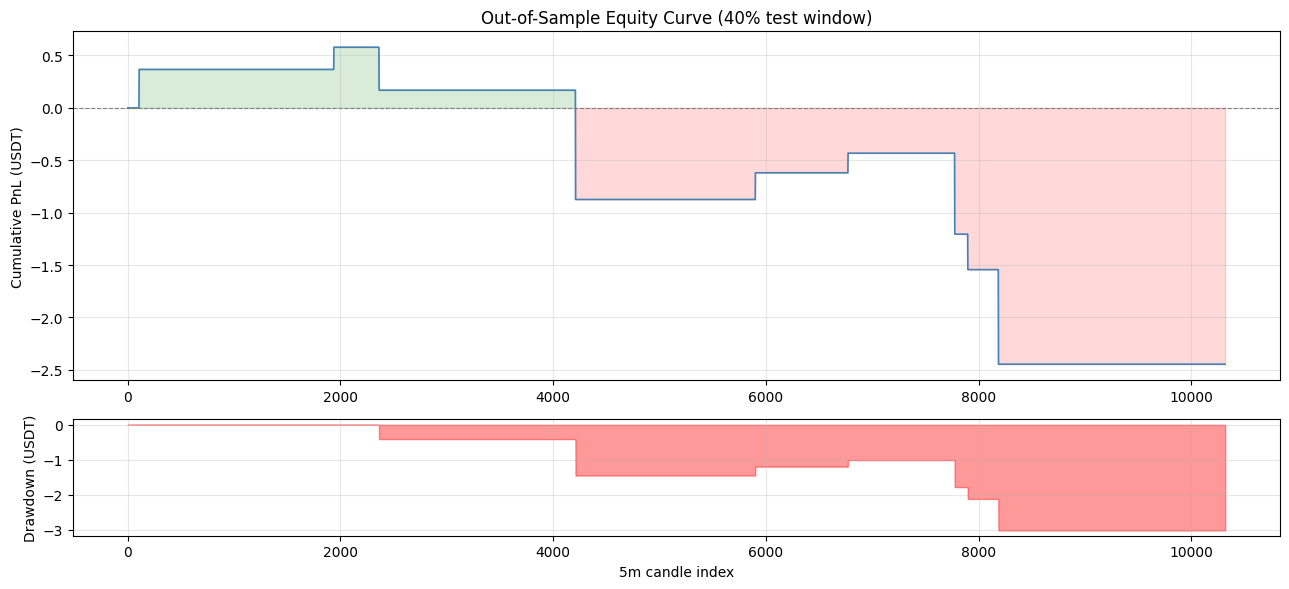

Peak: $0.5792  Final: $-2.4464  Max DD: $-3.0256


In [55]:
# Cell F — Out-of-sample equity curve + drawdown
import matplotlib.pyplot as plt
from src.backtest.runner import run_backtest

split  = int(len(candles) * 0.6)
equity = run_backtest(candles[split:], params, cfg)['equity_curve']
peak   = 0.0
dds    = [((peak := max(peak, e)), e - peak)[1] for e in equity]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [3,1]})
ax1.plot(equity, lw=1.2, color='steelblue')
ax1.axhline(0, color='gray', ls='--', lw=0.8)
ax1.fill_between(range(len(equity)), equity, 0, where=[e>=0 for e in equity], alpha=0.15, color='green')
ax1.fill_between(range(len(equity)), equity, 0, where=[e<0  for e in equity], alpha=0.15, color='red')
ax1.set_title('Out-of-Sample Equity Curve (40% test window)', fontsize=12)
ax1.set_ylabel('Cumulative PnL (USDT)'); ax1.grid(True, alpha=0.3)
ax2.fill_between(range(len(dds)), dds, 0, color='red', alpha=0.4)
ax2.set_ylabel('Drawdown (USDT)'); ax2.set_xlabel('5m candle index'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Peak: ${max(equity) if equity else 0:.4f}  Final: ${equity[-1] if equity else 0:.4f}  Max DD: ${min(dds) if dds else 0:.4f}')